<a href="https://colab.research.google.com/github/jan49-ship-it/alfido-tech-internship-tasks-/blob/main/Deep_Learning_Image_Classification_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [3]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

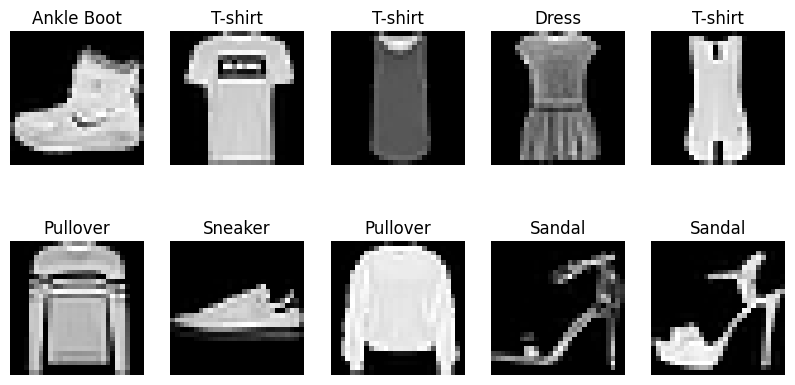

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [6]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)

datagen.fit(X_train)

In [7]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    datagen.flow(X_train,y_train,batch_size=64),
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 80ms/step - accuracy: 0.6960 - loss: 0.8180 - val_accuracy: 0.7942 - val_loss: 0.5268
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 0.7685 - loss: 0.6111 - val_accuracy: 0.8162 - val_loss: 0.4632
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 73s 78ms/step - accuracy: 0.7979 - loss: 0.5392 - val_accuracy: 0.8519 - val_loss: 0.3954
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 75ms/step - accuracy: 0.8162 - loss: 0.4933 - val_accuracy: 0.8678 - val_loss: 0.3505
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.8287 - loss: 0.4629 - val_accuracy: 0.8782 - val_loss: 0.3407
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 76ms/step - accuracy: 0.8389 - loss: 0.4387 - val_accuracy: 0.8814 - val_loss: 0.3244
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.8436 - loss: 0.4285 - val_accuracy: 0.8724 - val_loss: 0.3424
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.8470 - loss: 0.4158 - 

In [10]:
loss,accuracy=model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8853 - loss: 0.3053
Test Accuracy: 0.8852999806404114


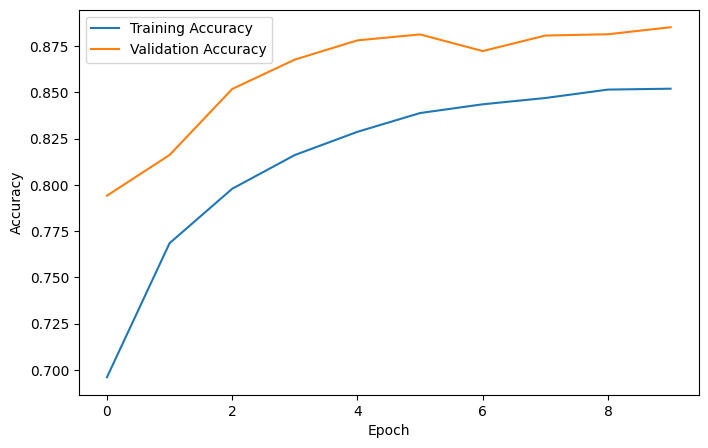

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

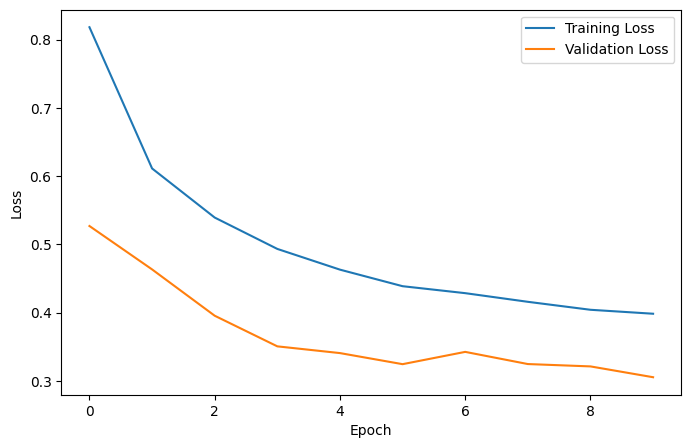

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [13]:
predictions=model.predict(X_test)

predicted_classes=np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [14]:
print(classification_report(y_test,predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

     T-shirt       0.81      0.86      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.81      0.86      0.83      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.84      0.74      0.78      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.64      0.65      0.64      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.97      0.98      0.97      1000
  Ankle Boot       0.98      0.95      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



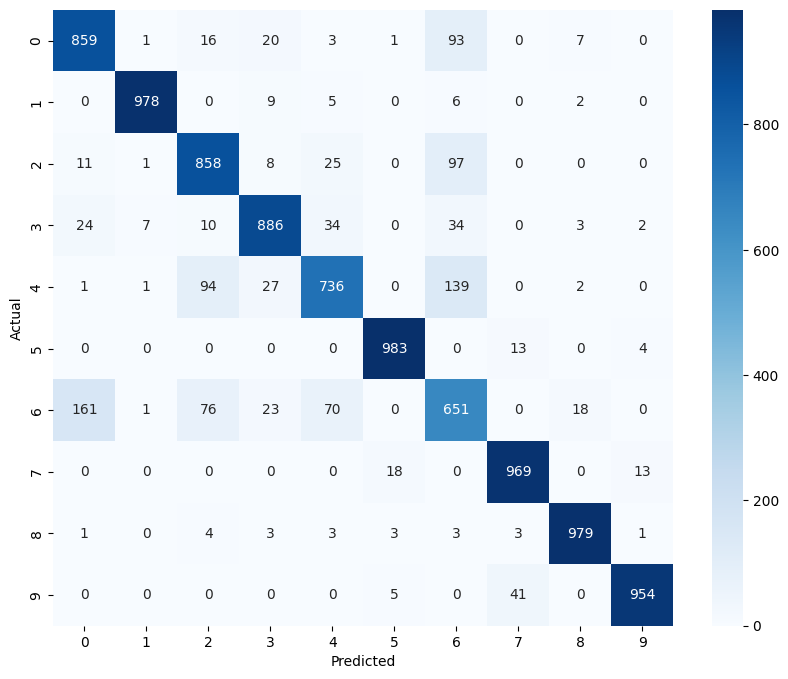

In [15]:
cm=confusion_matrix(y_test,predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

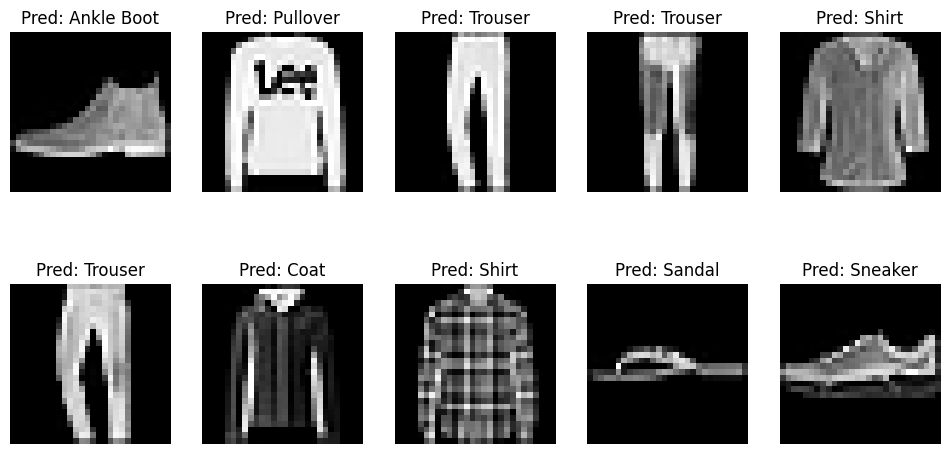

In [16]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28),cmap='gray')

    plt.title("Pred: "+class_names[predicted_classes[i]])

    plt.axis("off")

plt.show()

In [17]:
model.save("fashion_mnist_model.keras")

In [24]:
from tensorflow.keras.models import load_model

In [25]:
saved_model = load_model("fashion_mnist_model.keras")

In [20]:
from google.colab import files

files.download("fashion_mnist_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>